## 2. d)
Implementiere den Algorithmus in Python.

In [3]:
def merge_sort(lst):
    if len(lst) <= 1:
        return lst
    else:
        m=len(lst)//2
        a=merge_sort(lst[:m])
        b=merge_sort(lst[m:])
        i=j=0
        c=[]
        while i < len(a) and j < len(b):
            if a[i]<b[j]:
                c.append(a[i])
                i += 1
            else:
                c.append(b[j])
                j += 1
        c.extend(a[i:])
        c.extend(b[j:])
        return c
            


In [4]:
lst = [38, 27, 43, 3, 9, 82, 10]
print("Unsortierte Liste:", lst)
sorted_lst = merge_sort(lst)
print("Sortierte Liste:", sorted_lst)

Unsortierte Liste: [38, 27, 43, 3, 9, 82, 10]
Sortierte Liste: [3, 9, 10, 27, 38, 43, 82]


## 3. d)
Implementiere den Algorithmus und miss die Laufzeit.

In [8]:
def fib_dyn(n):
    if n == 0:
        return 0,1
    else:
        curr, next = fib_dyn(n-1)
        return next, next + curr

In [11]:
from timeit import default_timer as timer  #import des default_timer als timer (ist nur neuer Name) aus der Bibliotek timeit 

m = 10                          #Anzahl der Durchläufe pro Länge (um Systemschwankungen herauszumitteln)
N = list(range(30))             #Erzeugt eine Liste mit den Einträgen [0,1,2,...,29]
times = [0] * len(N)            #Erzeugt die Liste für die Durchschnittszeiten für jede Länge, erstmal sind alle auf 0 gesetzt

for j in range(len(N)): 
    temptimes = 0               #Zeitenzwischenspeicher wird auf 0 gesetzt
    for i in range(m):          
        start = timer()         #schreibt in start die aktuelle Zeit

        #Hier könnte dein Algorithmus stehen
        fib_dyn(N[j])

        end = timer()           #schreibt in end die aktuelle Zeit
        temptimes += end-start  #addiert die Zeitdifferenzen von jedem Schleifendurchlauf auf
    times[j] = temptimes/m      #bildet die Durchschnittszeit auf den m Durchläufen und speichert sie in times an der j-ten Position

print(times)  #Ausgabe der Zeiten in Sekunden

[3.0420487746596335e-07, 3.0819792300462724e-07, 3.458058927208185e-07, 4.500965587794781e-07, 4.541943781077862e-07, 5.789974238723517e-07, 6.166985258460044e-07, 5.710055120289325e-07, 6.373855285346508e-07, 7.002032361924648e-07, 7.583003025501966e-07, 8.000992238521576e-07, 8.62503657117486e-07, 9.624985978007316e-07, 1.037493348121643e-06, 1.1169002391397953e-06, 1.1668947990983724e-06, 1.2208940461277961e-06, 1.3041950296610595e-06, 1.3874960131943226e-06, 1.4626944903284312e-06, 1.5333876945078374e-06, 1.6167934518307447e-06, 1.6710022464394569e-06, 1.7417187336832285e-06, 1.8127146176993847e-06, 1.8711027223616838e-06, 1.9587052520364525e-06, 2.0126055460423233e-06, 2.091802889481187e-06]


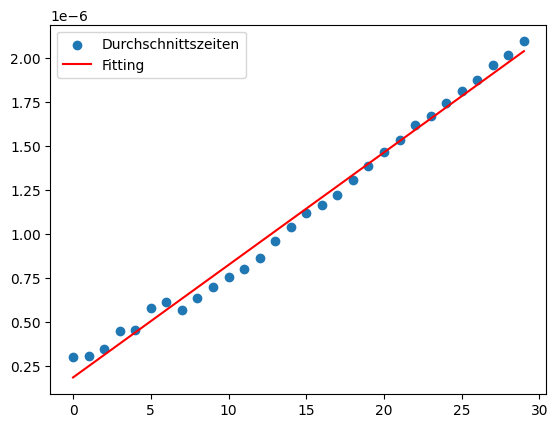

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = N       #N ist die Liste mit Längen von den Listen, die wir aufsummieren 
y = times   #times ist die Liste mit Laufzeiten für die jeweiligen Längen 

coefficients = np.polyfit(x, y, deg=1)  #Fitten eines Polynom 1-ten Grades an die Laufzeiten
poly_func = np.poly1d(coefficients)     #Erzeugen einer Funktion basierend auf dem Fitting 
y_fit = poly_func(x)                    #Erzeugen der Liste mit y-Werten basierend auf dem Fitting, 
                                        #   als x-Werte werden wieder die Längen genutzt

plt.scatter(x, y, label='Durchschnittszeiten')     #vorbereiten Daten plotten
plt.plot(x, y_fit, label='Fitting', color='red')   #vorbereiten Fitting plotten
plt.legend()                                       #vorbereiten Legende plotten
plt.show()                                         #Plot anzeigen